<a href="https://colab.research.google.com/github/lihenryhfl/old.lihenryhfl.github.io/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Demucs

Demucs is a music source seperation model from Facebook. Provide it a song and it will seperate the track into individual files containing drums, bass, vocals, and "other".

[Github Repo](https://github.com/facebookresearch/demucs)

In [ ]:
!pip install demucs

     |████████████████████████████████| 51kB 4.0MB/s 
  Created wheel for demucs: filename=demucs-2.0.0-cp37-none-any.whl size=40321 sha256=4e19c605974fab29d514d878c4af1f79b88852e1375e93b93d72971f87b29fcb
  Stored in directory: /root/.cache/pip/wheels/1b/62/34/a269377601fef46a0204bfd9075e4eacf5e5df3c36dc2beaba
  Created wheel for diffq: filename=diffq-0.1.0-cp37-none-any.whl size=18833 sha256=8177c6d87b3853ad101f07daae0d7ae423afde37cb3caf5c8cc69b7e700f8524
  Stored in directory: /root/.cache/pip/wheels/b8/cd/4f/ea4e66ed99250c243fda1d1d910e2b3cce21c3305d33deb928
Successfully built demucs diffq


Upload your file to Colab, then copy the path below:

In [ ]:
!python -m demucs.separate /path/to/wav/file

Downloading: "https://dl.fbaipublicfiles.com/demucs/v3.0/demucs_quantized-07afea75.th" to /root/.cache/torch/hub/checkpoints/demucs_quantized-07afea75.th
100% 148M/148M [00:02<00:00, 68.4MB/s]
Separated tracks will be stored in /content/demucs/separated/demucs_quantized
Separating track /content/rushing-back-clip.wav
100%|██████████████████████████████████████████████████████████████████████████| 30.0/30.0 [00:21<00:00,  1.42seconds/s]


In [3]:
data.shape

(463826, 2)

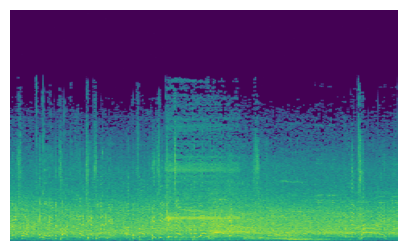

In [21]:
import matplotlib.pyplot as plt
from scipy.io import wavfile
import numpy as np

In [124]:
import math
import scipy
def normalize_audio(audio: np.ndarray) -> np.ndarray:
  """Normalizes audio to the range [-1, 1].

  Args:
    audio: A numpy array representing the audio data.

  Returns:
    A numpy array representing the normalized audio data.
  """
  max_abs_val = np.max(np.abs(audio))
  if max_abs_val > 0:
    return audio / max_abs_val
  return audio

def resample_audio(
    original_audio: np.ndarray,
    original_sample_rate: int,
    target_sample_rate: int,
) -> np.ndarray:
  """Resamples audio to a target sample rate using scipy.signal.resample_poly.

  This function uses scipy.signal.resample_poly for efficient resampling.
  It calculates the greatest common divisor (GCD) between the target and
  original sample rates to find the simplest upsampling and downsampling
  factors.

  Args:
    original_audio: A numpy array containing the audio samples.
    original_sample_rate: The sample rate of the original audio in Hz.
    target_sample_rate: The desired sample rate in Hz.

  Returns:
    A numpy array containing the resampled audio samples.
  """
  if original_sample_rate == target_sample_rate:
    return original_audio

  common_divisor = math.gcd(int(target_sample_rate), int(original_sample_rate))
  up = int(target_sample_rate // common_divisor)
  down = int(original_sample_rate // common_divisor)

  resampled_audio = scipy.signal.resample_poly(original_audio, up, down, axis=0)
  return resampled_audio

def process_audio_pipeline(audio_data: np.ndarray, original_sr: int = 44100, target_sr: int = 16000) -> np.ndarray:
  """Normalizes and resamples an audio signal.

  Args:
    audio_data: Input mono audio data as a NumPy array with shape (n_samples,).
    original_sr: The original sample rate of the audio data.
    target_sr: The target sample rate for resampling.

  Returns:
    The processed audio data as a NumPy array.
  """
  if audio_data.ndim != 1:
    raise ValueError(f"Expected audio data to be 1-dimensional, but got shape {audio_data.shape}")

  # # 1. Normalize the audio data
  # normalized_audio = normalize_audio(audio_data)
  normalized_audio = audio_data

  # 2. Resample the audio data
  resampled_audio = resample_audio(normalized_audio, original_sr, target_sr)

  return resampled_audio

# audio = orig_audio.mean(axis=1)

In [140]:
names = [
    './trimmed_basketball.wav',
    './ufloss_bkgd.wav',
    './nixie_bkgd.wav',
    './ufloss_narration.wav',
    './nixie_narration.wav'
    ]

def plot(name, ax=None, vmin=25):
  samplerate, data = wavfile.read(name)
  if data.ndim > 1:
    data = data.mean(axis=-1)
  if samplerate > 16_000:
    data = process_audio_pipeline(data)
    samplerate = 16_000

  print(samplerate)
  if ax is not None:
    ax.specgram(
        data + 1e-7 * np.random.normal(data.shape),
        Fs=samplerate,
        NFFT=1024,
        vmin=-vmin,
    )
    ax.axis('off')
  else:
    plt.figure(figsize=(5, 3))
    plt.specgram(
        data + 1e-7 * np.random.normal(data.shape),
        Fs=samplerate,
        NFFT=1024,
        vmin=-vmin,
    )
    plt.axis('off')

  path = '/content/' + name.split('.')[1] + '.png'
  print('saving to', path)
  plt.savefig(path, transparent=True)

  return None

16000
saving to /content//trimmed_basketball.png


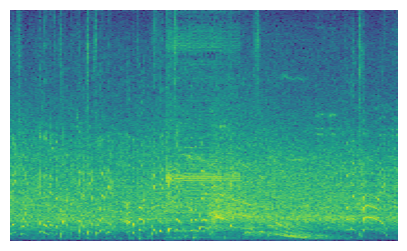

In [141]:
plot(names[0])

16000
saving to /content//ufloss_bkgd.png


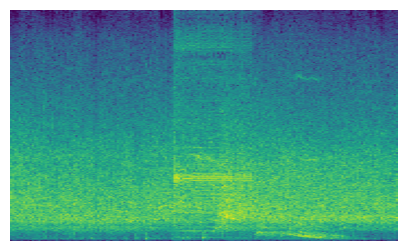

In [142]:
plot(names[1])

16000
saving to /content//nixie_bkgd.png


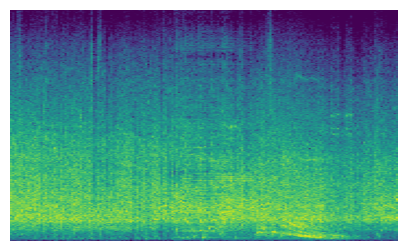

In [143]:
plot(names[2])

16000
saving to /content//ufloss_narration.png


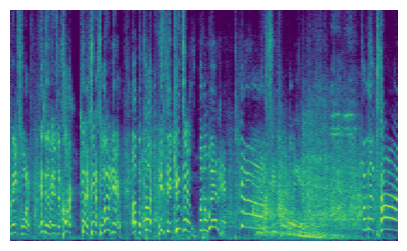

In [144]:
plot(names[3])

16000
saving to /content//nixie_narration.png


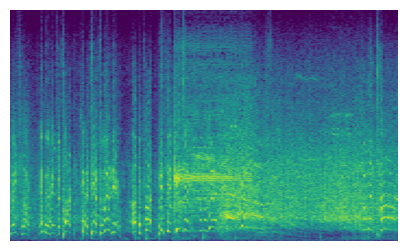

In [145]:
plot(names[4])